In [ ]:
from google.colab import drive
drive.mount('/content/gdrive')

Mounted at /content/gdrive


In [ ]:
import matplotlib.pyplot as plt



def plot_history_list(histories, param_name, paramList, max_epochs=None, save_filepath=None):
    """
    Plots Loss and F1-Score curves. Links Train/Val visually by color.
    """
    if not isinstance(histories, list) or not histories:
        print("Error: Input must be a non-empty list of Keras History objects.")
        return

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    # Get the default matplotlib color cycle to ensure train/val share a color
    prop_cycle = plt.rcParams['axes.prop_cycle']
    colors = prop_cycle.by_key()['color']

    def get_data(key):
        # Helper to parse to max epoch
        return hist[key][:max_epochs] if key in hist else None

    for i, history in enumerate(histories):
        hist = history.history
        color = colors[i % len(colors)] # Assign one color per parameter value
        # label_prefix = f"{param_name}: {paramList[i]}"
        label_prefix = f"{paramList[i]}"


        # Identify F1 keys (handling Keras metric naming variations)
        f1_key = "f1score" if "f1score" in hist else "f1_score"
        val_f1_key = f"val_{f1_key}"

        # --- 1. Loss Plot ---
        train_loss = get_data("loss")
        val_loss = get_data("val_loss")

        if train_loss:
            axes[0].plot(train_loss, label=f"{label_prefix} (train)",
                         color=color, linestyle='-', marker='o', markersize=4, alpha=0.8)
        if val_loss:
            axes[0].plot(val_loss, label=f"{label_prefix} (val)",
                         color=color, linestyle='--', marker='x', markersize=4, alpha=0.9)

        # --- 2. F1-Score Plot ---
        train_f1 = get_data(f1_key)
        val_f1 = get_data(val_f1_key)

        if train_f1:
            axes[1].plot(train_f1, label=f"{label_prefix} (train)",
                         color=color, linestyle='-', marker='o', markersize=4, alpha=0.8)
            if val_f1:
                axes[1].plot(val_f1, label=f"{label_prefix} (val)",
                             color=color, linestyle='--', marker='x', markersize=4, alpha=0.9)

    # --- Formatting ---
    axes[0].set_title("Loss Comparison")
    axes[0].set_xlabel("Epochs")
    axes[0].set_ylabel("Loss")
    axes[0].grid(True, linestyle=':', alpha=0.6)


    if any(f1_key in h.history for h in histories):
        axes[1].set_title("F1-Score Comparison")
        axes[1].set_xlabel("Epochs")
        axes[1].set_ylabel("F1-Score")
        axes[1].grid(True, linestyle=':', alpha=0.6)
        axes[1].legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize='small')
    else:
        # only plot legend for left pannel if no right pannel
        axes[0].legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize='small')
        axes[1].set_visible(False)

    plt.suptitle(f"Impact of {param_name} on Training", fontsize=16)
    plt.tight_layout() # Standard tight_layout; adjusts subplots and legend

    if save_filepath:
        plt.savefig(save_filepath, bbox_inches='tight')
        print(f"Plot saved to: {save_filepath}")

    plt.show()

In [ ]:
%cd gdrive

/content/gdrive


In [ ]:
%ls MyDrive/ML2_projet/models_forclip/clip_flicker_long/*

MyDrive/ML2_projet/models_forclip/clip_flicker_long/flicker_long_no_data_augment_sequence_length_variation_sequence_length_128_15_epochs_history.csv
MyDrive/ML2_projet/models_forclip/clip_flicker_long/flicker_long_no_data_augment_sequence_length_variation_sequence_length_128_15_epochs.keras
MyDrive/ML2_projet/models_forclip/clip_flicker_long/flicker_long_no_data_augment_sequence_length_variation_sequence_length_32_15_epochs_history.csv
MyDrive/ML2_projet/models_forclip/clip_flicker_long/flicker_long_no_data_augment_sequence_length_variation_sequence_length_32_15_epochs.keras
MyDrive/ML2_projet/models_forclip/clip_flicker_long/flicker_long_no_data_augment_sequence_length_variation_sequence_length_64_15_epochs_history.csv
MyDrive/ML2_projet/models_forclip/clip_flicker_long/flicker_long_no_data_augment_sequence_length_variation_sequence_length_64_15_epochs.keras
MyDrive/ML2_projet/models_forclip/clip_flicker_long/flicker_long_var_data_augment_++_seq_length_128_numLayers_6_data_augmentatio

In [ ]:
import csv
import os

class MockHistory:
    """A dummy class to mimic the Keras History object structure."""
    def __init__(self, history_dict):
        self.history = history_dict

def load_history_csv(filename):
    """Loads a CSV file back into a Keras-like History object."""
    history_dict = {}

    with open(filename, "r") as f:
        reader = csv.DictReader(f)
        for row in reader:
            for key, value in row.items():
                if key not in history_dict:
                    history_dict[key] = []
                # Convert string values back to floats
                history_dict[key].append(float(value))

    return MockHistory(history_dict)

In [ ]:
%ls MyDrive/ML2_projet/models_forclip/clip_small_dataset*

MyDrive/ML2_projet/models_forclip/clip_small_dataset_base_batch_size_16_history.csv
MyDrive/ML2_projet/models_forclip/clip_small_dataset_base_batch_size_32_history.csv
MyDrive/ML2_projet/models_forclip/clip_small_dataset_base_batch_size_64_history.csv
MyDrive/ML2_projet/models_forclip/clip_small_dataset__better_cnn_better_shuffle_batch_size_64_history.csv
MyDrive/ML2_projet/models_forclip/clip_small_dataset__better_shuffle_batch_size_64_history.csv


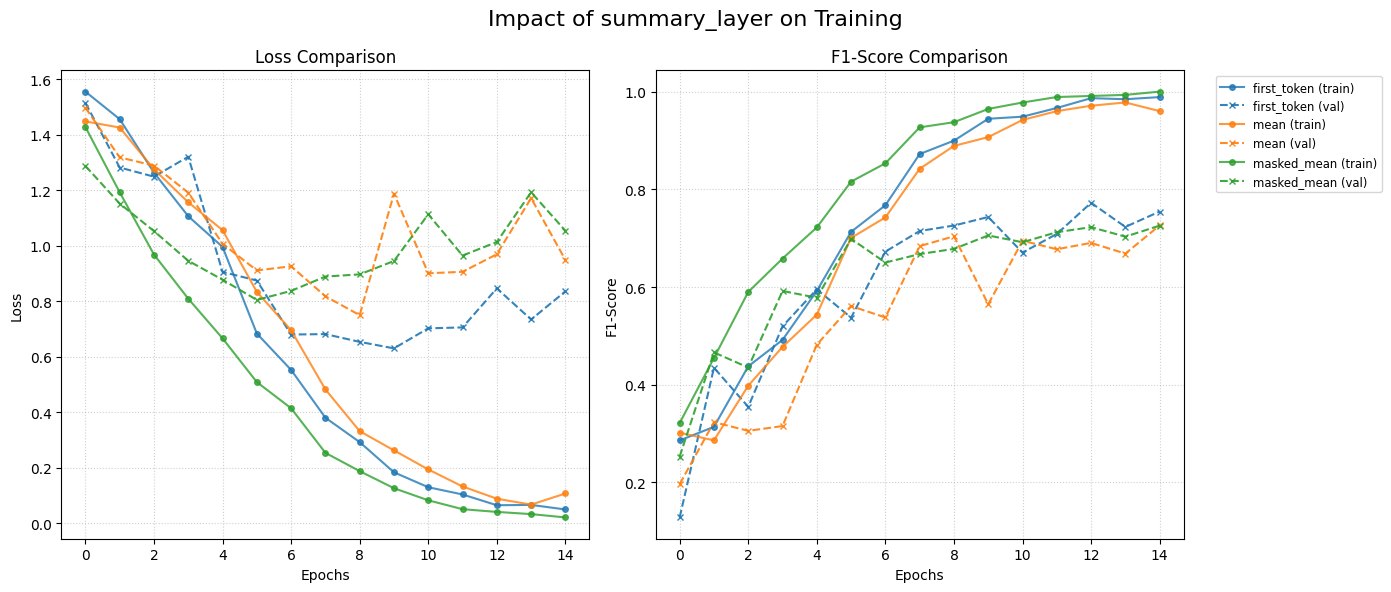

In [ ]:
history_file_dir = "MyDrive/ML2_projet/models_forclip"

history_filename_list = [
    "smallbert_classif_15_epoch_6_layers_summary_layer_first_token_history.csv",
    "smallbert_classif_15_epoch_6_layers_summary_layer_mean_history.csv",
    "smallbert_classif_15_epoch_6_layers_summary_layer_masked_mean_history.csv"
]

history_list = [load_history_csv(os.path.join(history_file_dir + filename)) for filename in history_filename_list]
plot_history_list(history_list, "summary_layer", ['first_token', 'mean', 'masked_mean'], save_filepath=None)


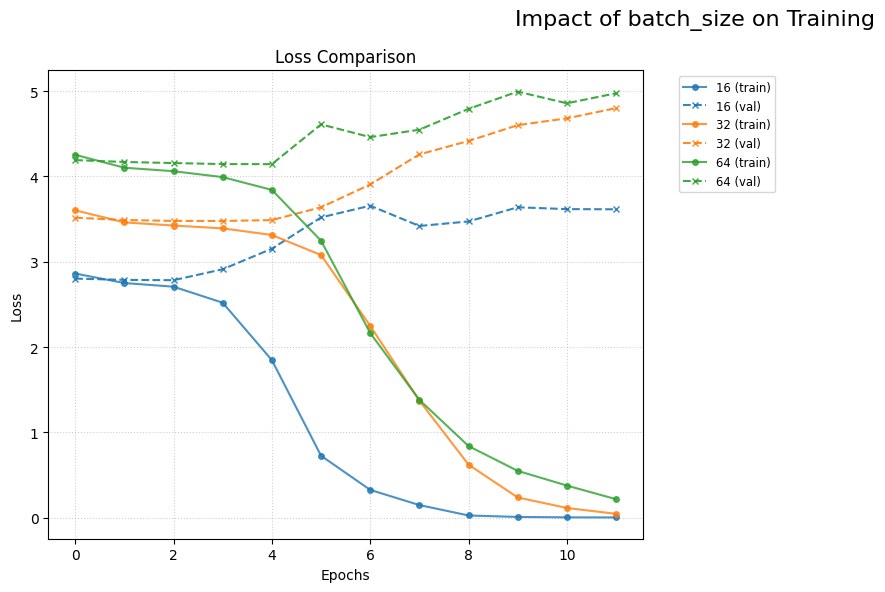

In [ ]:
# plot the CLIP base with batch size
history_file_dir = "MyDrive/ML2_projet/models_forclip"

history_filename_list = [
    "clip_small_dataset_base_batch_size_16_history.csv",
    "clip_small_dataset_base_batch_size_32_history.csv",
    "clip_small_dataset_base_batch_size_64_history.csv"
]

history_list = [load_history_csv(os.path.join(history_file_dir, filename)) for filename in history_filename_list]
plot_history_list(history_list, "batch_size", ['16', '32', '64'], max_epochs=12, save_filepath=None)


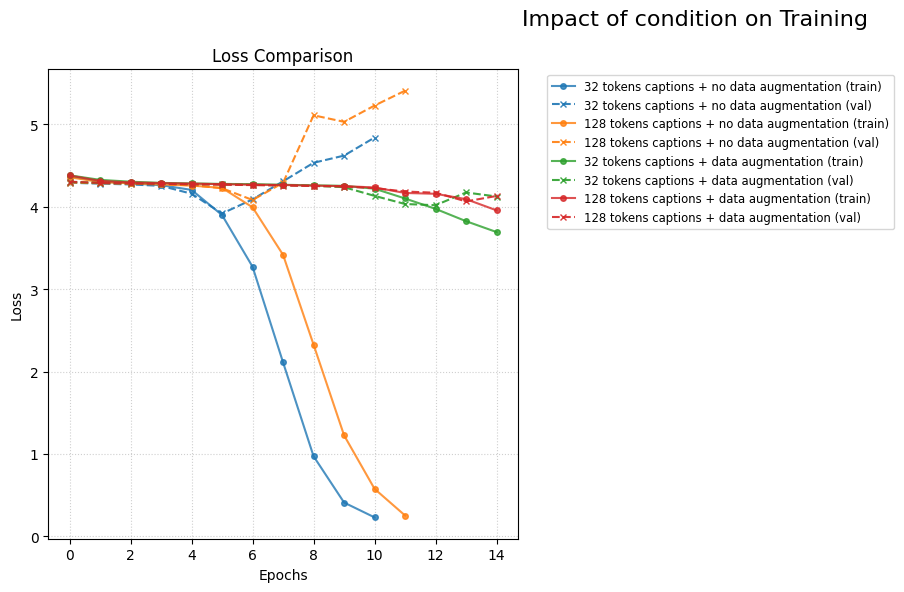

In [ ]:
# plot the CLIP improvement with increased data complexity
history_file_dir = "MyDrive/ML2_projet/models_forclip/clip_flicker_long"

history_filename_list = [
    "flicker_long_no_data_augment_sequence_length_variation_sequence_length_32_15_epochs_history.csv",
    "flicker_long_no_data_augment_sequence_length_variation_sequence_length_128_15_epochs_history.csv",
    "flicker_long_with_data_augment_++_var_seq_length_sequence_length_32_15_epochs_history.csv",
    "flicker_long_with_data_augment_++_var_seq_length_sequence_length_128_15_epochs_history.csv"
]

history_list = [load_history_csv(os.path.join(history_file_dir, filename)) for filename in history_filename_list]
plot_history_list(history_list, "condition", [
    '32 tokens captions + no data augmentation',
    '128 tokens captions + no data augmentation',
    '32 tokens captions + data augmentation',
    '128 tokens captions + data augmentation'], max_epochs=15, save_filepath=None)

In [ ]:
flicker_long_no_data_augment_sequence_length_variation_sequence_length_32_15_epochs_history.csv